In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# K is width, D is number of hidden units in each layer
def init_params(K, D):
  # Set seed so we always get the same random numbers
  np.random.seed(1)

  # Input layer
  D_i = 1
  # Output layer
  D_o = 1

  # Glorot initialization
  sigma_sq_omega = 1.0/D

  # Make empty lists
  all_weights = [None] * (K+1)
  all_biases = [None] * (K+1)

  # Create parameters for input and output layers
  all_weights[0] = np.random.normal(size=(D, D_i))*np.sqrt(sigma_sq_omega)
  all_weights[-1] = np.random.normal(size=(D_o, D)) * np.sqrt(sigma_sq_omega)
  all_biases[0] = np.random.normal(size=(D,1))* np.sqrt(sigma_sq_omega)
  all_biases[-1]= np.random.normal(size=(D_o,1))* np.sqrt(sigma_sq_omega)

  # Create intermediate layers
  for layer in range(1,K):
    all_weights[layer] = np.random.normal(size=(D,D))*np.sqrt(sigma_sq_omega)
    all_biases[layer] = np.random.normal(size=(D,1))* np.sqrt(sigma_sq_omega)

  return all_weights, all_biases

In [18]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [19]:
def forward_pass(net_input, all_weights, all_biases):

  # Retrieve number of layers
  K = len(all_weights) -1

  # We'll store the pre-activations at each layer in a list "all_f"
  # and the activations in a second list[all_h].
  all_f = [None] * (K+1)
  all_h = [None] * (K+1)

  #For convenience, we'll set
  # all_h[0] to be the input, and all_f[K] will be the output
  all_h[0] = net_input

  # Run through the layers, calculating all_f[0...K-1] and all_h[1...K]
  for layer in range(K):
      # Update preactivations and activations at this layer according to eqn 7.5
      all_f[layer] = all_biases[layer] + np.matmul(all_weights[layer], all_h[layer])
      all_h[layer+1] = ReLU(all_f[layer])

  # Compute the output from the last hidden layer
  all_f[K] = all_biases[K] + np.matmul(all_weights[K], all_h[K])

  # Retrieve the output
  net_output = all_f[K]

  return net_output, all_f, all_h

In [20]:
# We'll need the indicator function
def indicator_function(x):
  x_in = np.array(x)
  x_in[x_in>=0] = 1
  x_in[x_in<0] = 0
  return x_in

In [21]:
# Main backward pass routine
def calc_input_output_gradient(x_in, all_weights, all_biases):

  # Run the forward pass
  y, all_f, all_h = forward_pass(x_in, all_weights, all_biases)

  # We'll store the derivatives dl_dweights and dl_dbiases in lists as well
  all_dl_dweights = [None] * (K+1)
  all_dl_dbiases = [None] * (K+1)
  # And we'll store the derivatives of the loss with respect to the activation and preactivations in lists
  all_dl_df = [None] * (K+1)
  all_dl_dh = [None] * (K+1)
  # Again for convenience we'll stick with the convention that all_h[0] is the net input and all_f[k] in the net output

  # Compute derivatives of net output with respect to loss
  all_dl_df[K] = np.ones_like(all_f[K])

  # Now work backwards through the network
  for layer in range(K,-1,-1):
    all_dl_dbiases[layer] = np.array(all_dl_df[layer])
    all_dl_dweights[layer] = np.matmul(all_dl_df[layer], all_h[layer].transpose())

    all_dl_dh[layer] = np.matmul(all_weights[layer].transpose(), all_dl_df[layer])

    if layer > 0:
      all_dl_df[layer-1] = indicator_function(all_f[layer-1]) * all_dl_dh[layer]


  return all_dl_dh[0],y

In [22]:
D = 200; K = 3
# Initialize parameters
all_weights, all_biases = init_params(K,D)

x = np.ones((1,1))
dydx,y = calc_input_output_gradient(x, all_weights, all_biases)

# Offset for finite gradients
delta = 0.00000001
x1 = x
y1,*_ = forward_pass(x1, all_weights, all_biases)
x2 = x+delta
y2,*_ = forward_pass(x2, all_weights, all_biases)
# Finite difference calculation
dydx_fd = (y2-y1)/delta

print("Gradient calculation=%f, Finite difference gradient=%f"%(dydx,dydx_fd))

Gradient calculation=0.013250, Finite difference gradient=0.013250


C:\Users\Admin\AppData\Local\Temp\ipykernel_16576\1705960967.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Gradient calculation=%f, Finite difference gradient=%f"%(dydx,dydx_fd))


In [24]:
def plot_derivatives(K, D):

  # Initialize parameters
  all_weights, all_biases = init_params(K,D)

  x_in = np.arange(-2,2, 4.0/256.0)
  x_in = np.resize(x_in, (1,len(x_in)))
  dydx,y = calc_input_output_gradient(x_in, all_weights, all_biases)

  fig,ax = plt.subplots()
  ax.plot(np.squeeze(x_in), np.squeeze(dydx), 'b-')
  ax.set_xlim(-2,2)
  ax.set_xlabel(r'Input, x')
  ax.set_ylabel(r'Gradient, dy\dx')
  ax.set_title('No layers = %d'%(K))
  plt.show()
     

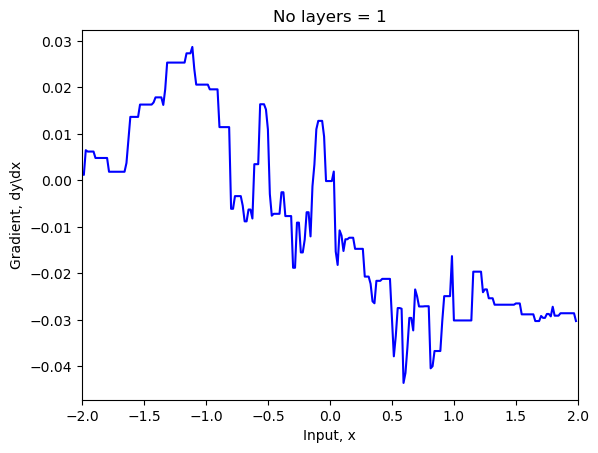

In [25]:
D = 200; K = 1
plot_derivatives(K,D)

We see that with K = 1 and a little change of data - gradient is quite stable, showing that loss surface is not very complex sinve we used only one hidden layer

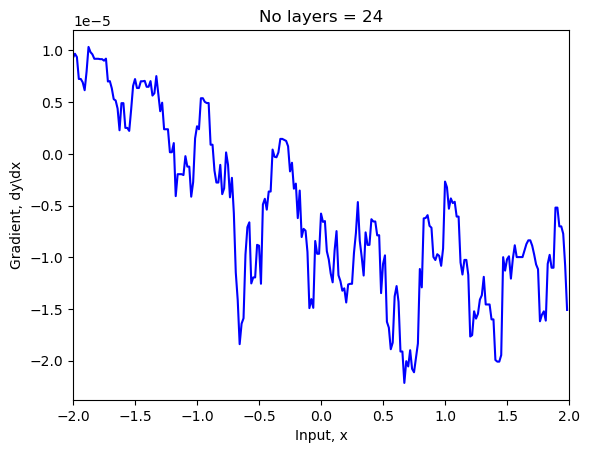

In [26]:
D = 200; K = 24
plot_derivatives(K,D)

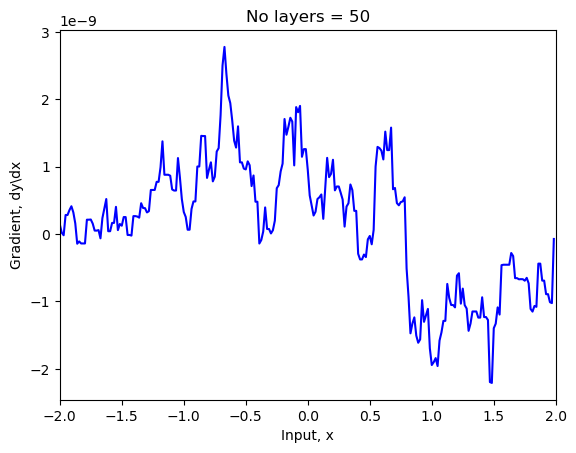

In [27]:
D = 200; K = 50
plot_derivatives(K,D)

In [28]:
def autocorr(dydx):
  ac = np.correlate(dydx, dydx, mode="same")
  
  return ac

In [29]:
def plot_autocorr(K, D):

  # Initialize parameters
  all_weights, all_biases = init_params(K,D)

  x_in = np.arange(-2.0,2.0, 4.0/256)
  x_in = np.resize(x_in, (1,len(x_in)))
  dydx,y = calc_input_output_gradient(x_in, all_weights, all_biases)
  ac = autocorr(np.squeeze(dydx))
  ac = ac / ac[128]

  y = ac[128:]
  x = np.squeeze(x_in)[128:]
  fig,ax = plt.subplots()
  ax.plot(x,y, 'b-')
  ax.set_xlim([0,2])
  ax.set_xlabel('Distance')
  ax.set_ylabel('Autocorrelation')
  ax.set_title('No layers = %d'%(K))
  plt.show()

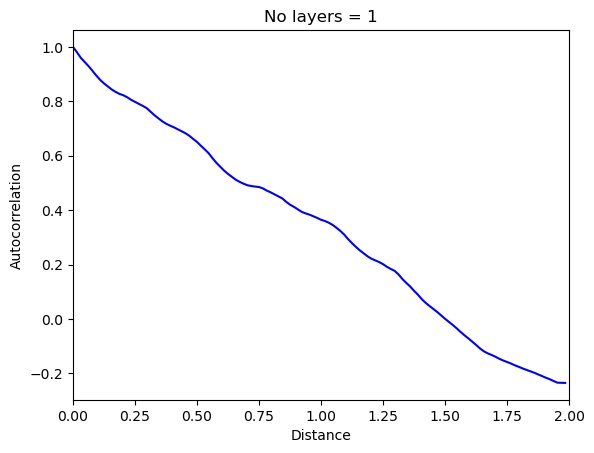

In [30]:
# Plot the autocorrelation functions
D = 200; K =1
plot_autocorr(K,D)

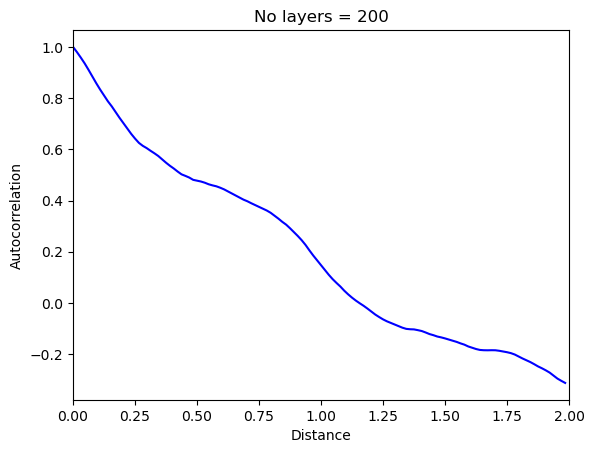

In [32]:
# Plot the autocorrelation functions
D = 200; K =200
plot_autocorr(K,D)